In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- ÉTAPE 1 : Configuration et chargement des données ---
# On définit l'apparence des futurs graphiques (taille et style).
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Chargement du fichier CSV contenant les 15 000 dossiers médicaux.
path = "../divers/"
data = pd.read_csv(path + "healthcare_synthetic_data.csv", sep=",", header=0)
print(f"Dimensions du jeu de données : {data.shape[0]} lignes, {data.shape[1]} colonnes")

# On indique à Python quelles variables sont des catégories (qualitatives).
# 'ordered=False' pour les catégories sans ordre (ex: Genre).
# 'ordered=True' pour celles qui ont une progression (ex: Niveau d'activité physique).
data["Gender"] = pd.Categorical(data["Gender"], ordered=False)
data["Smoking_Status"] = pd.Categorical(data["Smoking_Status"], ordered=False)
data["Alcohol_Consumption"] = pd.Categorical(data["Alcohol_Consumption"], ordered=True)
data["Physical_Activity_Level"] = pd.Categorical(data["Physical_Activity_Level"], ordered=True)
data["Family_History"] = pd.Categorical(data["Family_History"], ordered=False)

# --- ÉTAPE 2 : Nettoyage et typage des variables ---
# On supprime la colonne 'Patient_ID' car l'identifiant n'aide pas à prédire le cholestérol.
data = data.drop('Patient_ID', axis=1)
data2 = data.drop('Heart_Disease_Risk', axis=1)


# --- ÉTAPE 3 : Transformation pour les algorithmes (Encodage) ---
# On liste les variables numériques (quantitatives).
var_quant = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP", "Diastolic_BP",
             "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
             "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours"]

# 'get_dummies' transforme les catégories de texte en chiffres (0 ou 1) exploitables par le réseau de neurones.
# 'drop_first=True' permet d'alléger les données en évitant les colonnes redondantes.
dataQuant = data[var_quant]
dataDum = pd.get_dummies(data[["Gender", "Smoking_Status", "Alcohol_Consumption",
                                "Physical_Activity_Level", "Family_History"]],
                         drop_first=True)

# On rassemble les variables numériques et les catégories transformées dans un seul tableau final 'dataC'.
dataC = pd.concat([dataDum, dataQuant], axis=1)

# --- ÉTAPE 4 : Préparation spécifique pour la régression du Cholestérol LDL ---
# On isole la cible 'Yr' : ce que l'on veut prédire (le mauvais cholestérol).
Yr = data["Cholesterol_LDL"]


# On sépare les données en deux groupes : 
# 1. Un groupe pour l'entraînement (80%) pour que le réseau apprenne.
# 2. Un groupe "Test" (20%, soit 3000 lignes) pour vérifier s'il est devenu performant.
# On retire bien sûr 'Cholesterol_LDL' des variables explicatives pour ne pas donner la réponse au modèle.
X_train_r, X_test_r, Y_train_cholest, Y_test_cholest = train_test_split(
    dataC.drop("Cholesterol_LDL", axis=1), Yr, test_size=3000, random_state=11)

# --- ÉTAPE 5 : Standardisation ---
# Les réseaux de neurones sont très sensibles aux différences d'échelle (ex: Age entre 0-100 vs Cholestérol 0-300).
# 'StandardScaler' met toutes les variables sur la même échelle de valeur.
scaler_r = StandardScaler()

# On calcule les réglages de mise à l'échelle sur le groupe d'entraînement uniquement (fit).
scaler_r.fit(X_train_r)

# On applique ces réglages aux deux groupes (transform).
Xr_train_r = scaler_r.transform(X_train_r)
Xr_test_r = scaler_r.transform(X_test_r)

print("Données prêtes pour le réseau de neurones !")


Dimensions du jeu de données : 15000 lignes, 19 colonnes
Données prêtes pour le réseau de neurones !


/home/deleri/Documents/4A/Analyse_Données/Exploration/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/deleri/Documents/4A/Analyse_Données/Exploration/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/deleri/Documents/4A/Analyse_Données/Exploration/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/deleri/Documents/4A/Analyse_Données/Exploration/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: 

Meilleur score R2 en validation : 0.685
Meilleurs paramètres : {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (5,)}

--- Évaluation sur l'échantillon Test ---
MSE (Erreur Quadratique Moyenne) : 106.7822
R2 (Coefficient de détermination) : 0.6643


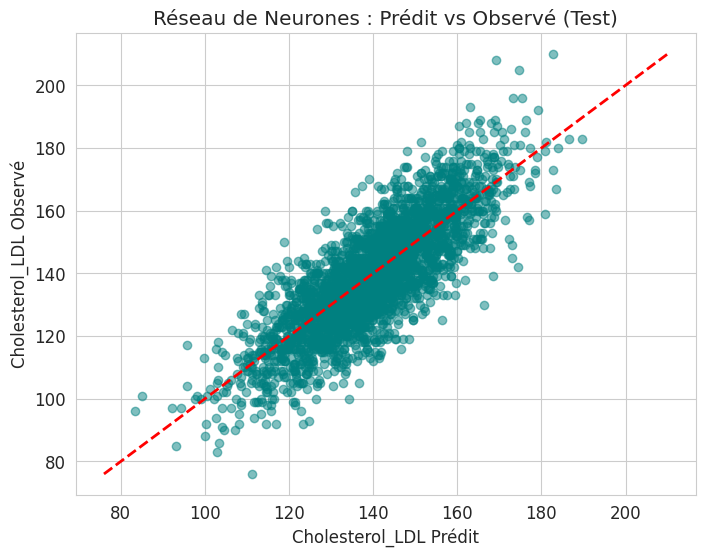

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Définition de la grille d'hyperparamètres à tester
# hidden_layer_sizes : (10,) signifie une couche de 10 neurones, (10, 5) deux couches.
# alpha : paramètre de régularisation pour éviter le surapprentissage (overfitting).
param_grid = [
    {
        'hidden_layer_sizes': [(5,), (10,), (10, 5), (20,),(20,15,11,14,8,7)],
        'alpha': [0.001, 0.01, 0.1],
        'activation': ['relu', 'tanh']
    }
]

# 2. Initialisation du modèle avec un nombre d'itérations suffisant pour la convergence
nnet = MLPRegressor(max_iter=1000, random_state=11)

# 3. Optimisation par validation croisée (5-fold)
# n_jobs=-1 utilise tous les processeurs de ton ordinateur pour aller plus vite.
nnet_grid = GridSearchCV(nnet, param_grid, cv=5, n_jobs=-1, scoring='r2')
nnet_opt = nnet_grid.fit(Xr_train_r, Y_train_cholest)

# 4. Affichage du meilleur modèle trouvé
print(f"Meilleur score R2 en validation : {nnet_opt.best_score_.round(4)}")
print(f"Meilleurs paramètres : {nnet_opt.best_params_}")

# 5. Évaluation finale sur l'échantillon TEST
Y_pred_cholest = nnet_opt.predict(Xr_test_r)



print("\n--- Évaluation sur l'échantillon Test ---")
# On utilise round(valeur, decimales) au lieu de valeur.round(decimales)
print(f"MSE (Erreur Quadratique Moyenne) : {round(mean_squared_error(Y_test_cholest, Y_pred_cholest), 4)}")
print(f"R2 (Coefficient de détermination) : {round(r2_score(Y_test_cholest, Y_pred_cholest), 4)}")

# 6. Graphique des résidus pour vérifier la qualité de la prédiction
plt.figure(figsize=(8, 6))
plt.scatter(Y_pred_cholest, Y_test_cholest, alpha=0.5, color='teal')
plt.plot([Y_test_cholest.min(), Y_test_cholest.max()], 
         [Y_test_cholest.min(), Y_test_cholest.max()], 'r--', lw=2)
plt.xlabel("Cholesterol_LDL Prédit")
plt.ylabel("Cholesterol_LDL Observé")
plt.title("Réseau de Neurones : Prédit vs Observé (Test)")
plt.show()

Meilleurs paramètres: Les meilleurs paramètres retenus sont une couche d'activation relou, une seule couche cachée de 5 neurones, ainsi qu'un alpha (force de régularisation) de 0.001.

Résultats: On explique 66% de la variance du Cholestérol LDL à partir des variables et avec le réseau de neurones.
La racine de 106 vaut environ 10, cela signifie qu'en moyenne on se trompe de 10 mg/dl sur le taux de Cholestérol ce qui est assez précis.
0.66 est très proche de 0.685 ce qui signifie qu'on ne fait pas d'overfitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- ÉTAPE 1 : Configuration et chargement des données ---
# On définit l'apparence des futurs graphiques (taille et style).
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Chargement du fichier CSV contenant les 15 000 dossiers médicaux.
path = "../divers/"
data = pd.read_csv(path + "healthcare_synthetic_data.csv", sep=",", header=0)
print(f"Dimensions du jeu de données : {data.shape[0]} lignes, {data.shape[1]} colonnes")

# On indique à Python quelles variables sont des catégories (qualitatives).
# 'ordered=False' pour les catégories sans ordre (ex: Genre).
# 'ordered=True' pour celles qui ont une progression (ex: Niveau d'activité physique).
data["Gender"] = pd.Categorical(data["Gender"], ordered=False)
data["Smoking_Status"] = pd.Categorical(data["Smoking_Status"], ordered=False)
data["Alcohol_Consumption"] = pd.Categorical(data["Alcohol_Consumption"], ordered=True)
data["Physical_Activity_Level"] = pd.Categorical(data["Physical_Activity_Level"], ordered=True)
data["Family_History"] = pd.Categorical(data["Family_History"], ordered=False)

# --- ÉTAPE 2 : Nettoyage et typage des variables ---
# On supprime la colonne 'Patient_ID' car l'identifiant n'aide pas à prédire le cholestérol.
data = data.drop('Patient_ID', axis=1)
data2 = data.drop('Heart_Disease_Risk', axis=1)


# --- ÉTAPE 3 : Transformation pour les algorithmes (Encodage) ---
# On liste les variables numériques (quantitatives).
var_quant = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP", "Diastolic_BP",
             "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
             "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours"]

# 'get_dummies' transforme les catégories de texte en chiffres (0 ou 1) exploitables par le réseau de neurones.
# 'drop_first=True' permet d'alléger les données en évitant les colonnes redondantes.
dataQuant = data[var_quant]
dataDum = pd.get_dummies(data[["Gender", "Smoking_Status", "Alcohol_Consumption",
                                "Physical_Activity_Level", "Family_History"]],
                         drop_first=True)

# On rassemble les variables numériques et les catégories transformées dans un seul tableau final 'dataC'.
dataC = pd.concat([dataDum, dataQuant], axis=1)

#--- ÉTAPE 4: Préparation pour la classification du Risque Cardiaque ---

# On isole la cible 'Yb' (Variable binaire : 0 ou 1) 
Yb = data["Heart_Disease_Risk"].astype(int) 

# On sépare les données (20% pour le test, soit 3000 lignes) 
# Ici, X_train contient TOUTES les variables de dataC sauf la cible 'Heart_Disease_Risk' si elle y était.
# Note : Cholesterol_LDL est ici une variable explicative, donc on la garde. 
X_train, X_test, Y_train_risk, Y_test_risk = train_test_split(
    dataC, Yb, test_size=3000, random_state=11)

# --- ÉTAPE 5 : Standardisation ---
# La standardisation reste obligatoire pour le MLPClassifier
scaler = StandardScaler()
scaler.fit(X_train)

Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)

print("Données prêtes pour la classification !")



Dimensions du jeu de données : 15000 lignes, 19 colonnes
Données prêtes pour la classification !


In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Grille d'optimisation (recherche du meilleur nombre de neurones)
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (10, 5)], 
    'alpha': [0.001, 0.01],
    'activation': ['relu', 'tanh']
}

# 2. Création du modèle de classification
# 'max_iter=1000' pour laisser le temps au réseau de converger
nnet_class = MLPClassifier(max_iter=1000, random_state=11)

# 3. Optimisation par validation croisée (10-fold comme dans le notebook Ozone)
nnet_grid = GridSearchCV(nnet_class, param_grid, cv=10, n_jobs=-1)
nnet_opt = nnet_grid.fit(Xr_train, Y_train_risk)

print(f"Meilleurs paramètres : {nnet_opt.best_params_}")
print(f"Meilleur score en validation : {nnet_opt.best_score_.round(4)}")

Meilleurs paramètres : {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (5,)}
Meilleur score en validation : 0.7396


In [5]:
# Prédiction sur l'échantillon test
Y_pred_risk = nnet_opt.predict(Xr_test)

# Matrice de confusion pour voir les erreurs de prédiction
conf_matrix = pd.crosstab(Y_pred_risk, Y_test_risk, rownames=['Prédit'], colnames=['Réel'])
print("\nMatrice de Confusion :")
print(conf_matrix)

# Calcul du taux d'erreur
erreur = 1 - accuracy_score(Y_test_risk, Y_pred_risk)
# Syntaxe : round(valeur, nombre_de_decimales)
print(f"\nTaux d'erreur sur le test : {round(erreur, 4)}")




Matrice de Confusion :
Réel       0    1
Prédit           
0       1342  490
1        328  840

Taux d'erreur sur le test : 0.2727


Erreur de 27%.
Meilleurs paramètres : {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (5,)}